# Analog transmon-controlled beamsplitter from two simultaneous sidebands

An evaluation of the scheme proposed in Slack:

> turn on Q1C1 swap at rate $g_1$, detuning $d_1$; turn on Q1C2 swap at rate $g_2$,
> detuning $-d_1$ — when expanding the system Hamiltonian, at 2nd order the term
> $\sigma_q(a^\dagger b + ab^\dagger)$ will appear … because there will also be terms
> like $\sigma_z n_a$ and $\sigma_z n_b$ appearing now as the "dynamical chi" … now
> appropriate qubit echo might need to be introduced.

This walks it through from the **lab Hamiltonian** with 3-wave mixing, into the
**rotating frame**, does the **second-order Schrieffer–Wolff** transformation, and then
evaluates numerically how well the gate actually works. The transmon is modelled as a
**Kerr oscillator** (so $f$ and above are included), $\omega_{ge}/2\pi=4.6$ GHz and
$\alpha/2\pi=-150$ MHz.

**Headline: the idea works and the structure is better than expected — but two details in
the Slack sketch need correcting, and the achievable fidelity is limited.**

| finding | status |
|---|---|
| the three 2nd-order terms are exactly as described | ✔ confirmed to $10^{-16}$ |
| **opposite** detunings $d_2=-d_1$ make the conditional BS vanish *identically* | ✘ needs $d_2=+d_1$ |
| the three terms assemble into $\sigma_z n_-$, whose exponential **is** the c-SWAP | ✔ better than expected |
| a qubit echo is needed | ✘ no — an echo that removes the dynamical $\chi$ **destroys** the gate |
| $f$ level is a nuisance | ✘ it is *part of the mechanism* — omit it and the gate is wrong ($F=0.36$ vs $0.78$), and it *speeds the gate up* ~2× |
| fidelity | reaches $10^{-4}$ only at $g\,T\approx190$ (total $N\le8$), i.e. $\sim23\times$ slower than a synthesised pulse at equal fidelity and equal Fock range |

**Every fidelity here is quoted with the Fock range it was scored on.** The error grows
with photon number, so a bare fidelity number for this gate is meaningless: at
$g/2\pi=2$ MHz, $\Delta/2\pi=40$ MHz the same pulse gives $F=0.99$ on Fock $0..1$,
$0.95$ on Fock $0..4$, and $0.78$ on Fock $0..8$.

---

## Notation

| symbol | code | meaning |
|---|---|---|
| $a_1,a_2$ | `a1`, `a2` | cavity annihilation operators |
| $q$ | `q` | transmon annihilation operator (Kerr oscillator, **not** $\sigma^-$) |
| $\omega_q$ | — | transmon $ge$ frequency, $2\pi\times4.6$ GHz |
| $\alpha$ | `alpha` | anharmonicity, $2\pi\times(-150)$ MHz, so $\omega_{ef}=\omega_q+\alpha$ |
| $g_j$ | `g`, `g1`, `g2` | activated sideband (conversion) rate, cavity $j$ ↔ transmon |
| $d_j$ | `d1`, `d2` | sideband detuning of pump $j$ |
| $\Delta$ | `Delta` | the common sideband detuning (once $d_1=d_2$ is imposed) |
| $\Delta\phi$ | `dphi` | relative phase of the two pumps, $\phi_2-\phi_1$ |
| $n_\pm$ | — | number operator of $a_\pm=(a_1\pm a_2)/\sqrt2$ |
| $G$ | — | bright-supermode coupling, $\sqrt{g_1^2+g_2^2}=\sqrt2\,g$ |
| $\chi_k$, $J_k$ | `chi`, `J` | 2nd-order coefficients of $(n_1+n_2)$ and of the BS term, on transmon level $k$ |
| $\delta\chi$ | `dchi` | conditional rate $\chi_e-\chi_g$ |
| $N_c$, $N_q$ | `Nc`, `Nq` | cavity / transmon truncation in the simulation |
| $T$ | `T` | gate duration; $g\,T$ is the figure of merit |

In [22]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import analog_cbs as ac

%load_ext autoreload
%autoreload 2

# All rates are angular frequencies in rad/us, so dividing by TWOPI reads out in MHz.
TWOPI = 2 * np.pi
W_GE = 4600.0 * TWOPI      # transmon ge frequency
ALPHA = -150.0 * TWOPI     # anharmonicity (ef sits 150 MHz below ge)
G_SB = 2.0 * TWOPI         # activated sideband rate g

print("w_ge/2pi =", W_GE / TWOPI, "MHz")
print("alpha/2pi =", ALPHA / TWOPI, "MHz")
print("w_ef/2pi =", (W_GE + ALPHA) / TWOPI, "MHz")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
w_ge/2pi = 4600.0 MHz
alpha/2pi = -150.0 MHz
w_ef/2pi = 4450.0 MHz


## 1. The lab Hamiltonian, and where the sideband terms come from

### 1a. Bare modes

Two cavities and one transmon. The transmon is a **Kerr oscillator**, not a two-level
system, so the whole ladder $g,e,f,h,\dots$ is present:

$$H_{\rm modes}=\omega_1a_1^\dagger a_1+\omega_2a_2^\dagger a_2
+\omega_qq^\dagger q+\frac{\alpha}{2}q^\dagger q^\dagger q q$$

The Kerr term $\frac{\alpha}{2}q^\dagger q^\dagger qq=\frac{\alpha}{2}n_q(n_q-1)$ gives

$$E_k=\omega_qk+\frac{\alpha}{2}k(k-1)
\quad\Longrightarrow\quad \omega_{k\to k+1}=\omega_q+\alpha k$$

so $\omega_{ge}=\omega_q=2\pi\times4.6$ GHz and $\omega_{ef}=\omega_q+\alpha
=2\pi\times4.45$ GHz — the $ef$ transition 150 MHz below $ge$, as specified.

### 1b. The 3-wave-mixing element

A 3WM coupler (SNAIL / ATS) contributes a **cubic** term in the total flux across it.
Writing that flux as a sum of the participating modes' zero-point contributions,
$\hat\varphi\propto\sum_i(a_i+a_i^\dagger)$ including a stiff pump mode $p$,

$$H_3=g_3\Big(\varphi_1(a_1+a_1^\dagger)+\varphi_2(a_2+a_2^\dagger)
+\varphi_q(q+q^\dagger)+\varphi_p(p+p^\dagger)\Big)^3$$

Treat the pump classically, $p\to\xi_je^{-i\omega_{pj}t}$. Expanding the cube and keeping
the terms **linear in the pump** and containing one cavity and one transmon operator gives,
among many others, the pair

$$H\supset\;\underbrace{6g_3\varphi_j\varphi_q\varphi_p\,\xi_j}_{\textstyle \equiv\,g_j}
\;\left(a_j^\dagger q\;e^{-i\omega_{pj}t}+\mathrm{h.c.}\right)+\dots$$

All the other cubic products either fail to conserve energy by GHz amounts (and drop out
under the RWA) or are the unwanted processes one designs the pump frequency to avoid.
**The activated rate $g_j$ is proportional to the pump amplitude $\xi_j$** — that is the
knob.

### 1c. Frequency matching

Go to the frame rotating at each mode's own frequency,
$a_j\to a_je^{-i\omega_jt}$, $q\to qe^{-i\omega_qt}$. The retained term becomes

$$g_j\left(a_j^\dagger q\,e^{i(\omega_j-\omega_q-\omega_{pj})t}+\mathrm{h.c.}\right)
\;\equiv\;g_j\left(a_j^\dagger q\,e^{i d_jt}+\mathrm{h.c.}\right)$$

so choosing the pump at $\omega_{pj}=\omega_j-\omega_q$ makes cavity $j$ ↔ transmon photon
conversion **resonant**, and

$$\boxed{\;d_j=\omega_j-\omega_q-\omega_{pj}\;}$$

is the **sideband detuning** — the quantity called $d_1$, $d_2$ in the Slack message. Adding
a pump phase $\phi_j$ and putting both pumps on:

$$H(t)=\sum_{j=1,2}g_j\left(e^{i(d_jt+\phi_j)}\,a_j^\dagger q+\mathrm{h.c.}\right)$$

### 1d. The one detail that drives everything below

**The coupling is to $q$, the transmon lowering operator, not to $\sigma^-$.** Since
$\langle k|q|k+1\rangle=\sqrt{k+1}$, a single pump drives *every* rung of the transmon
ladder at once. If it is resonant on $ge$, then on $ef$ it is off-resonant by exactly
$\alpha$ — and carries a matrix element $\sqrt2$ larger. Section 6 shows this is not a small
correction; it changes the gate rate by up to a factor 2.

## 2. Into a single rotating frame — and why $d_1$ must equal $d_2$

We want a frame in which $H$ is **time independent**, so that the gate is one static
Hamiltonian evolved for a time $T$. Try the most general passive frame generated by the
three number operators,

$$W(t)=\exp\!\big[-it\left(\lambda_1n_1+\lambda_2n_2+\lambda_qn_q\right)\big]$$

Under $W$, an operator $a_j^\dagger q$ picks up a phase: $a_j^\dagger\to a_j^\dagger
e^{+i\lambda_jt}$ and $q\to qe^{-i\lambda_qt}$, so

$$a_j^\dagger q\;\longrightarrow\;a_j^\dagger q\;e^{i(\lambda_j-\lambda_q)t}$$

The explicit $e^{id_jt}$ is cancelled only if

$$\lambda_j-\lambda_q=-d_j\qquad\text{for }j=1\text{ and }j=2$$

Two equations, and the overall frame offset is unphysical, so fix the cavities as the
static reference, $\lambda_1=\lambda_2=0$. Then both equations read $\lambda_q=d_1$ and
$\lambda_q=d_2$, which is consistent **only if**

$$\boxed{\;d_1=d_2\equiv\Delta\;}$$

Two readings of this:

* *Algebraically*, a single static frame exists only for equal sideband detunings. This is
  what the Slack line "$\text{detuning}\cdot\sigma_z+\text{JC}_1+\text{JC}_2$" already
  assumes — **one** detuning, carried by the transmon.
* *Physically*, converting a photon $a_1\to$ transmon $\to a_2$ has net detuning
  $d_1-d_2$. The Raman process is resonant exactly when $d_1=d_2$. With $d_2=-d_1$ it is
  off-resonant by $2d_1$, and section 4 shows the conditional beamsplitter then cancels
  **identically**.

Since $W$ is generated by $n_q$, it shifts the transmon frequency but leaves the Kerr term
alone ($n_q$ commutes with $n_q(n_q-1)$). The static Hamiltonian is therefore

$$\boxed{\;H=\Delta\,n_q+\frac{\alpha}{2}n_q(n_q-1)
+g_1\!\left(e^{i\phi_1}a_1^\dagger q+\mathrm{h.c.}\right)
+g_2\!\left(e^{i\phi_2}a_2^\dagger q+\mathrm{h.c.}\right)\;}$$

Only the pump **phase difference** $\Delta\phi=\phi_2-\phi_1$ is physical (a common phase is
absorbed into the cavity frames), and it will turn out to select which supermode the
transmon talks to. In the rotating frame the transmon levels sit at
$E_k=\Delta k+\frac{\alpha}{2}k(k-1)$, so

$$\text{$ge$ sideband detuned by }E_e-E_g=\Delta,\qquad
\text{$ef$ sideband detuned by }E_f-E_e=\Delta+\alpha$$

In [23]:
# --- check the Kerr ladder gives the right transition frequencies ---
Nq = 5
nq = qt.num(Nq)
H_transmon = W_GE * nq + 0.5 * ALPHA * nq * (nq - 1)
E = np.real(np.diag(H_transmon.full()))

print("transmon level energies / 2pi (MHz):", np.round(E / TWOPI, 1))
print("w_ge/2pi =", round((E[1] - E[0]) / TWOPI, 1), "MHz")
print("w_ef/2pi =", round((E[2] - E[1]) / TWOPI, 1), "MHz")

transmon level energies / 2pi (MHz): [    0.  4600.  9050. 13350. 17500.]
w_ge/2pi = 4600.0 MHz
w_ef/2pi = 4450.0 MHz


In [24]:
# --- the static rotating-frame Hamiltonian ---
ops = ac.make_ops(Nc=4, Nq=4)          # cavity1 (x) cavity2 (x) transmon
Delta = 40.0 * TWOPI                   # common sideband detuning

H = ac.rotating_frame_H(ops, g1=G_SB, g2=G_SB, Delta=Delta, alpha=ALPHA, dphi=np.pi)

print("H is Hermitian:", H.isherm)
print("ge sideband detuning /2pi =", round(Delta / TWOPI, 1), "MHz")
print("ef sideband detuning /2pi =", round((Delta + ALPHA) / TWOPI, 1),
      "MHz   <- not far away!")

H is Hermitian: True
ge sideband detuning /2pi = 40.0 MHz
ef sideband detuning /2pi = -110.0 MHz   <- not far away!


## 3. Second-order perturbation theory, done explicitly

Split $H=H_0+V$ with (two-level transmon for now; Kerr in section 6)

$$H_0=\Delta\,|e\rangle\langle e|,\qquad
V=\sum_j g_j\!\left(e^{i\phi_j}a_j^\dagger\sigma^-+e^{-i\phi_j}a_j\sigma^+\right)$$

$V$ is purely off-diagonal in the transmon: it changes the transmon level, so it has no
matrix elements within either branch. That is exactly the setting for a Schrieffer–Wolff
(dispersive) transformation.

### 3a. The transformation

Look for an anti-Hermitian $S=O(g/\Delta)$ such that $e^SHe^{-S}$ has no first-order
transmon-off-diagonal part. Using
$e^SHe^{-S}=H+[S,H]+\frac{1}{2!}[S,[S,H]]+\dots$ and writing $[S,H]=[S,H_0]+[S,V]$:

* impose $\;[S,H_0]=-V\;$ — this cancels $V$ at first order;
* then $[S,[S,H]]=[S,-V+[S,V]]=-[S,V]+O(g^3)$, so

$$e^SHe^{-S}=H_0+\underbrace{\Big(V+[S,H_0]\Big)}_{=\,0}+[S,V]-\tfrac12[S,V]+O(g^3)
=H_0+\tfrac12[S,V]+O(g^3)$$

$$\boxed{\;H^{(2)}=\tfrac12[S,V],\qquad [S,H_0]=-V\;}$$

Elementwise the condition $[S,H_0]=-V$ reads $S_{ij}(E_j-E_i)=-V_{ij}$, i.e.
$S_{ij}=V_{ij}/(E_i-E_j)$ — which is what the numerical check below implements. (Note
$S^\dagger=-S$ automatically, as required.)

### 3b. The commutator algebra

Group $V$ by which cavity it involves: $V=\sum_j(A_j+A_j^\dagger)$ with
$A_j=g_je^{i\phi_j}a_j^\dagger\sigma^-$. Each $A_j$ **lowers** the energy by $\Delta$, so
$[H_0,A_j]=-\Delta A_j$ and the solution of $[S,H_0]=-V$ is

$$S=-\frac{1}{\Delta}\sum_j\left(A_j-A_j^\dagger\right)$$

Now expand $H^{(2)}=\frac12[S,V]$:

$$H^{(2)}=-\frac{1}{2\Delta}\sum_{j,k}
\Big[A_j-A_j^\dagger,\;A_k+A_k^\dagger\Big]$$

The terms $[A_j,A_k]$ and $[A_j^\dagger,A_k^\dagger]$ **vanish identically** because they
contain $\sigma^-\sigma^-=0$ (or $\sigma^+\sigma^+=0$) — a two-level transmon cannot be
lowered twice. What survives is

$$H^{(2)}=-\frac{1}{2\Delta}\sum_{j,k}\Big([A_j,A_k^\dagger]+[A_k,A_j^\dagger]\Big)$$

Evaluate the two kinds of commutator using $[\sigma^-,\sigma^+]=|g\rangle\langle g|
-|e\rangle\langle e|=-\sigma_z$:

* **$j\ne k$ (cross terms).** $a_j^\dagger$ and $a_k$ commute, so
  $$[A_j,A_k^\dagger]=g_jg_ke^{i(\phi_j-\phi_k)}a_j^\dagger a_k[\sigma^-,\sigma^+]
  =-g_jg_ke^{i(\phi_j-\phi_k)}a_j^\dagger a_k\,\sigma_z$$
* **$j=k$ (diagonal terms).**
  $$[A_j,A_j^\dagger]=g_j^2\left(a_j^\dagger a_j\sigma^-\sigma^+-a_ja_j^\dagger\sigma^+\sigma^-\right)
  =g_j^2\Big(n_j|g\rangle\langle g|-(n_j+1)|e\rangle\langle e|\Big)$$

Putting it together, with $\Delta\phi=\phi_2-\phi_1$:

$$H^{(2)}=\underbrace{\frac{g_1^2}{\Delta}\,\sigma_z n_1+\frac{g_2^2}{\Delta}\,\sigma_z n_2}_{\text{"dynamical chi"}}
+\underbrace{\frac{g_1g_2}{\Delta}\,\sigma_z\!\left(e^{-i\Delta\phi}a_1^\dagger a_2+\mathrm{h.c.}\right)}_{\text{conditional beamsplitter}}
+\underbrace{\frac{g_1^2+g_2^2}{\Delta}|e\rangle\langle e|}_{\text{constant Stark shift}}$$

**These are exactly the three terms of the Slack message**, and they can be written in one
line:

$$\boxed{\;H^{(2)}=\frac{\sigma_z}{\Delta}\,B^\dagger B+\text{const},
\qquad B=g_1a_1+g_2e^{-i\Delta\phi}a_2\;}$$

### 3c. If the detunings are carried by the cavities instead

Repeating the same algebra with $H_0=d_1n_1+d_2n_2$ (independent detunings, no single
static frame) gives $A_j$ raising the energy by $d_j$, so $S=\sum_j\frac{1}{d_j}(A_j-A_j^\dagger)$
and the cross term acquires the *average* of the two inverse detunings:

$$\text{cross coefficient}=-\frac{g_1g_2}{2}\left(\frac{1}{d_1}+\frac{1}{d_2}\right)$$

which is the form used in the check below and in section 4.

In [25]:
def check_second_order(d1, d2, dphi, Nc=5, g1=1.0, g2=1.0):
    # Compare the numerical 2nd order with the analytic formula (two-level transmon)
    ops = ac.make_ops(Nc, 2)
    sigma_z = ops.P[1] - ops.P[0]
    identity = qt.qeye(ops.n1.dims[0])

    # H = H0 + V, with the detunings carried by the CAVITIES
    H0 = d1 * ops.n1 + d2 * ops.n2
    exchange1 = ops.a1.dag() * ops.q
    exchange2 = np.exp(1j * dphi) * ops.a2.dag() * ops.q
    V = g1 * (exchange1 + exchange1.dag()) + g2 * (exchange2 + exchange2.dag())

    H2_numeric = ac.sw_second_order(H0, V, ac.transmon_levels(ops))

    # the analytic result of section 3b
    cross = -(g1 * g2 / 2) * (1 / d1 + 1 / d2)
    bs = np.exp(-1j * dphi) * ops.a1.dag() * ops.a2
    H2_analytic = (cross * (bs + bs.dag()) * sigma_z
                   + (g1**2 / d1) * (ops.n1 * ops.P[0] - (ops.n1 + identity) * ops.P[1])
                   + (g2**2 / d2) * (ops.n2 * ops.P[0] - (ops.n2 + identity) * ops.P[1]))

    # compare on low-photon states, where the cavity truncation cannot matter
    rows = [ac.flat_index(ops, c1, c2, k)
            for c1 in range(Nc) for c2 in range(Nc) for k in range(2)
            if c1 + c2 <= Nc - 2]
    diff = (H2_numeric - H2_analytic).full()[np.ix_(rows, rows)]
    return np.max(np.abs(diff)), cross


print("numerical 2nd order vs the analytic formula:")
for d1, d2, dphi in [(30, 30, 0.0), (30, 30, np.pi), (20, 45, 0.0),
                     (40, 40, 0.22 * np.pi), (30, -30, 0.0)]:
    err, cross = check_second_order(float(d1), float(d2), dphi)
    print(f"  d1={d1:+5.0f}  d2={d2:+5.0f}  dphi={dphi/np.pi:+.2f}pi   "
          f"max error = {err:.1e}   cross coeff = {cross:+.6f}")

numerical 2nd order vs the analytic formula:
  d1=  +30  d2=  +30  dphi=+0.00pi   max error = 1.1e-16   cross coeff = -0.033333
  d1=  +30  d2=  +30  dphi=+1.00pi   max error = 1.1e-16   cross coeff = -0.033333
  d1=  +20  d2=  +45  dphi=+0.00pi   max error = 8.3e-17   cross coeff = -0.036111
  d1=  +40  d2=  +40  dphi=+0.22pi   max error = 5.6e-17   cross coeff = -0.025000
  d1=  +30  d2=  -30  dphi=+0.00pi   max error = 1.1e-16   cross coeff = -0.000000


## 4. Correction 1 — opposite detunings kill the conditional beamsplitter

From the formula just verified, the conditional-beamsplitter coefficient is

$$-\frac{g_1g_2}{2}\left(\frac{1}{d_1}+\frac{1}{d_2}\right)$$

so $d_2=-d_1$ makes it **exactly zero**. Physically: converting $a_1\to a_2$ through the
transmon has net detuning $d_1-d_2$, so it is resonant when $d_1=d_2$; with $d_2=-d_1$ the
conversion is off-resonant by $2d_1$ and the two virtual paths cancel. The dynamical-$\chi$
terms survive (they only need each sideband individually), so opposite detunings give you
the unwanted parity-type terms *and none of the beamsplitter*.

In [26]:
print("conditional-beamsplitter coefficient = -(g1 g2 / 2) (1/d1 + 1/d2):")
for d1, d2 in [(30, 30), (30, 60), (30, -60), (30, -31), (30, -30)]:
    cross = -(1 / 2) * (1 / d1 + 1 / d2)
    note = "   <-- EXACTLY ZERO, no gate" if abs(cross) < 1e-15 else ""
    print(f"  d1={d1:+5d}   d2={d2:+5d}   {cross:+.6f}{note}")

conditional-beamsplitter coefficient = -(g1 g2 / 2) (1/d1 + 1/d2):
  d1=  +30   d2=  +30   -0.033333
  d1=  +30   d2=  +60   -0.025000
  d1=  +30   d2=  -60   -0.008333
  d1=  +30   d2=  -31   -0.000538
  d1=  +30   d2=  -30   -0.000000   <-- EXACTLY ZERO, no gate


## 5. Why those three terms *are* a controlled SWAP — and why an echo would break it

### 5a. Collapse $B^\dagger B$ onto one supermode

Set $g_1=g_2=g$ and choose the pump relative phase $\Delta\phi=\pi$. Then

$$B=g_1a_1+g_2e^{-i\Delta\phi}a_2=g(a_1-a_2)=\sqrt2\,g\;a_-,
\qquad a_-\equiv\frac{a_1-a_2}{\sqrt2}$$

so with $G\equiv\sqrt2\,g$ (the bright-supermode coupling; note $\sqrt{g_1^2+g_2^2}$ is
maximal at equal amplitudes),

$$\boxed{\;H^{(2)}=\frac{G^2}{\Delta}\,\sigma_z\,n_-\;}\qquad n_-=a_-^\dagger a_-$$

The dynamical $\chi$ and the conditional beamsplitter are **not two separate effects**. Since

$$n_-=\tfrac12(n_1+n_2)-\tfrac12\!\left(a_1^\dagger a_2+a_2^\dagger a_1\right)$$

the $\sigma_zn_1,\sigma_zn_2$ terms are the $N$ half and the conditional beamsplitter is the
$J_x$ half of the **same** operator, locked in a fixed 1:1 ratio. (Choosing $\Delta\phi=0$
instead gives $n_+$ — the *symmetric* supermode — which is a different gate; see 5c.)

### 5b. $\exp$ of that is the controlled SWAP

$\mathrm{SWAP}_{12}=e^{i\pi n_-}$ **exactly**. Proof: $e^{i\pi n_-}$ conjugates
$a_-\to e^{i\pi}a_-=-a_-$ and leaves $a_+$ alone; from
$a_1=(a_++a_-)/\sqrt2$, $a_2=(a_+-a_-)/\sqrt2$ that is precisely $a_1\leftrightarrow a_2$,
and it fixes the vacuum. So write $\theta\equiv(G^2/\Delta)T$ and evolve:

$$U=e^{-iH^{(2)}T}=e^{-i\theta\sigma_zn_-}
=\begin{cases} e^{-i\theta n_-} & \text{on }|e\rangle\\[2pt]
e^{+i\theta n_-} & \text{on }|g\rangle\end{cases}$$

The two branches move **oppositely** — that is a factor 2 in hand for free. Take
$\theta=\pi/2$ and follow with the *unconditional* $e^{+i\frac{\pi}{2}n_-}$, which is one
50:50 cavity–cavity beamsplitter plus a virtual Z on each cavity (and which the free gauge in
the numerics supplies):

$$|e\rangle:\;e^{-i\frac\pi2n_-}e^{+i\frac\pi2n_-}=\mathbb{1},
\qquad
|g\rangle:\;e^{+i\frac\pi2n_-}e^{+i\frac\pi2n_-}=e^{i\pi n_-}=\mathrm{SWAP}$$

which is the transmon-controlled SWAP, with $|g\rangle$ the swapping branch. Timing:
$\theta=\pi/2$ means

$$T=\frac{\pi\Delta}{2G^2}=\frac{\pi\Delta}{4g^2},
\qquad g\,T=\frac{\pi}{4}\frac{\Delta}{g}\quad\text{(two-level estimate)}$$

### 5c. So: no echo

The Slack message anticipates needing "appropriate qubit echo" to deal with the
$\sigma_zn_a,\sigma_zn_b$ terms. But those terms are *half the gate*. An echo that cancelled
them — e.g. a qubit $\pi$ pulse at $T/2$ combined with flipping the sign of one sideband —
would leave only $\sigma_zJ_x$, i.e.

$$e^{-i\vartheta\sigma_zJ_x}\;=\;\text{controlled \emph{beamsplitter}, not controlled SWAP}$$

Concretely, $\sigma_z n_-$ generates a *reflection* of the two-mode space about $a_+$ (which
is what a SWAP is); $\sigma_zJ_x$ alone generates a rotation by an angle that never closes
into a permutation for all photon numbers at once. **Keep the dynamical $\chi$.**

Two related traps worth naming:

* $\Delta\phi=0$ gives $H^{(2)}\propto\sigma_zn_+$, and
  $e^{i\pi n_+}=e^{i\pi N}e^{-i\pi n_-}=e^{i\pi N}\cdot\mathrm{SWAP}$. The extra
  $e^{i\pi N}$ appears on **one branch only**, so it is a conditional total-photon parity —
  a genuinely different (and generally unwanted) gate. The relative pump phase must be $\pi$.
* $g_1\ne g_2$ makes $B\propto g_1a_1-g_2a_2$, a *tilted* supermode, and
  $e^{i\pi n_{\rm tilted}}$ is a reflection about the wrong axis — an error first order in the
  imbalance. Equal rates matter.

In [27]:
# --- SWAP = exp(i pi n_minus) exactly? ---
Nc = 8
b1 = qt.tensor(qt.destroy(Nc), qt.qeye(Nc))
b2 = qt.tensor(qt.qeye(Nc), qt.destroy(Nc))
a_minus = (b1 - b2) / np.sqrt(2)

U_parity = (1j * np.pi * a_minus.dag() * a_minus).expm()
U_swap = ac.swap_operator(Nc)
rows = [n1 * Nc + n2 for n1 in range(Nc) for n2 in range(Nc) if n1 + n2 <= Nc - 1]
err = np.max(np.abs((U_parity - U_swap).full()[np.ix_(rows, rows)]))
print("max |exp(i pi n_minus) - SWAP| =", f"{err:.1e}")

# --- and is H_eff = (G^2/Delta) sigma_z n_minus when dphi = pi? ---
Nc = 5
ops = ac.make_ops(Nc, 2)
sigma_z = ops.P[1] - ops.P[0]

H0 = Delta * ops.nq
exchange1 = ops.a1.dag() * ops.q
exchange2 = np.exp(1j * np.pi) * ops.a2.dag() * ops.q
V = G_SB * (exchange1 + exchange1.dag()) + G_SB * (exchange2 + exchange2.dag())

H2 = ac.sw_second_order(H0, V, ac.transmon_levels(ops))

G_super = np.sqrt(2) * G_SB                       # bright-supermode coupling
H2_predicted = ((G_super**2 / Delta) * sigma_z * ops.n_minus
                + (2 * G_SB**2 / Delta) * ops.P[1])

rows = [ac.flat_index(ops, c1, c2, k)
        for c1 in range(Nc) for c2 in range(Nc) for k in range(2)
        if c1 + c2 <= Nc - 2]
diff = (H2 - H2_predicted).full()[np.ix_(rows, rows)]
print("max |H2 - (G^2/Delta) sigma_z n_minus - const| =", f"{np.max(np.abs(diff)):.1e}")
print("=> the three second-order terms are one conditional phase on n_minus.")

max |exp(i pi n_minus) - SWAP| = 3.2e-15
max |H2 - (G^2/Delta) sigma_z n_minus - const| = 2.2e-16
=> the three second-order terms are one conditional phase on n_minus.


## 6. Putting the Kerr ladder back in — the $f$ level *helps*

Everything above used a two-level transmon. Now redo the second order with the real Kerr
oscillator, where the sideband couples to $q$ and so also drives $e\!\to\!f$.

### 6a. Per-level shifts

In the rotating frame $E_k=\Delta k+\frac{\alpha}{2}k(k-1)$. Level $k$ can virtually

* **absorb** a cavity photon, $|k\rangle\to|k+1\rangle$: matrix element $g\sqrt{k+1}$,
  energy denominator $E_k-E_{k+1}=-(\Delta+\alpha k)$;
* **emit** a cavity photon, $|k\rangle\to|k-1\rangle$: matrix element $g\sqrt{k}$,
  energy denominator $E_k-E_{k-1}=+(\Delta+\alpha(k-1))$.

Summing the two second-order contributions gives the coefficient of $(n_1+n_2)$ — and, by
the same cross-term algebra as section 3b, the *identical* coefficient for the beamsplitter,
so the $n_-$ structure survives:

$$\chi_k=g^2\left[\frac{k+1}{-(\Delta+\alpha k)}+\frac{k}{\Delta+\alpha(k-1)}\right]$$

$$\chi_g=-\frac{g^2}{\Delta},\qquad
\chi_e=g^2\!\left[\frac{1}{\Delta}-\frac{2}{\Delta+\alpha}\right]$$

The $|e\rangle$ shift now has a second piece: the $\sqrt2$-enhanced push against $|f\rangle$,
detuned by $\Delta+\alpha$. The **conditional rate** — the only thing the gate cares about —
is the difference:

$$\boxed{\;\delta\chi\equiv\chi_e-\chi_g
=g^2\!\left[\frac{2}{\Delta}-\frac{2}{\Delta+\alpha}\right]
=\frac{2g^2\,\alpha}{\Delta(\Delta+\alpha)}\;}$$

against the two-level value $2g^2/\Delta$. With $\alpha<0$ and $0<\Delta<|\alpha|$ the
denominator $\Delta(\Delta+\alpha)$ is negative, so $\delta\chi>0$ and **larger** than the
two-level result: at $\Delta/2\pi=40$ MHz by 36%, at 80 MHz by ~2×. **The $f$ level makes the
gate faster, and a two-level estimate of the gate time is simply wrong.**

### 6b. The resulting time, and where the sweet spot is

$T=\pi/(2\delta\chi)$, so with $u\equiv\Delta/|\alpha|$,

$$g\,T=\frac{\pi}{4}\,\frac{|\alpha|}{g}\;u(1-u)$$

This is *largest* (worst) at $u=1/2$ and shrinks towards either end — but $u\to0$ destroys
the dispersive approximation ($\Delta\lesssim g\sqrt{n}$) and $u\to1$ runs into the $ef$
sideband resonance at $\Delta=-\alpha$, where real leakage into $|f\rangle$ takes over. The
gate is therefore squeezed from both sides, which is what limits the fidelity in section 7.

The cell below checks $\chi_k$, confirms $\chi_k=J_k$ (the $n_-$ structure) at every level and
detuning, verifies the closed form for $\delta\chi$, and shows that $N_q=3$ already captures
everything — i.e. $|f\rangle$ matters and $|h\rangle$ does not.

In [28]:
ops = ac.make_ops(Nc=6, Nq=4)

print("per-level second-order coefficients (Kerr transmon)")
print("chi_k == J_k is what makes the gate a SWAP; closed form should match dchi")
print()
print(f"{'D/2pi':>7} {'ef det':>7} {'chi_g':>9} {'chi_e':>9} {'J_e':>9} "
      f"{'dchi':>9} {'closed':>9} {'|chi-J|':>9} {'resid':>8}")
for D_MHz in (16, 24, 32, 40, 60, 90, 120):
    Delta_i = D_MHz * TWOPI
    coeffs = ac.fit_level_coefficients(ops, G_SB, Delta_i, ALPHA)

    chi_g = np.real(coeffs[0]["chi"])
    chi_e = np.real(coeffs[1]["chi"])
    J_e = np.real(coeffs[1]["J"])
    dchi = chi_e - chi_g
    closed = ac.dchi_closed_form(G_SB, Delta_i, ALPHA)
    chi_minus_J = max(abs(coeffs[k]["chi"] - coeffs[k]["J"]) for k in range(4))
    resid = max(coeffs[k]["resid"] for k in range(4))

    print(f"{D_MHz:7.0f} {(Delta_i+ALPHA)/TWOPI:7.0f} {chi_g/TWOPI:9.4f} "
          f"{chi_e/TWOPI:9.4f} {J_e/TWOPI:9.4f} {dchi/TWOPI:9.4f} "
          f"{closed/TWOPI:9.4f} {chi_minus_J/TWOPI:9.1e} {resid/TWOPI:8.1e}")

print()
print("does |f> matter?  does |h>?")
for D_MHz in (40, 80):
    Delta_i = D_MHz * TWOPI
    rates = [ac.conditional_rate(G_SB, Delta_i, ALPHA, Nq=Nq)[0] / TWOPI
             for Nq in (2, 3, 4, 5)]
    two_level = 2 * G_SB**2 / Delta_i / TWOPI
    print(f"  Delta/2pi={D_MHz:3.0f}: dchi/2pi for Nq=2,3,4,5 ="
          f" {rates[0]:.4f} {rates[1]:.4f} {rates[2]:.4f} {rates[3]:.4f}"
          f"   (two-level {two_level:.4f}, so |f> gives {rates[-1]/rates[0]:.2f}x)")

per-level second-order coefficients (Kerr transmon)
chi_k == J_k is what makes the gate a SWAP; closed form should match dchi

  D/2pi  ef det     chi_g     chi_e       J_e      dchi    closed   |chi-J|    resid
     16    -134   -0.2500    0.3097    0.3097    0.5597    0.5597   1.4e-16  1.1e-15
     24    -126   -0.1667    0.2302    0.2302    0.3968    0.3968   1.8e-16  5.7e-16
     32    -118   -0.1250    0.1928    0.1928    0.3178    0.3178   7.1e-17  4.2e-16
     40    -110   -0.1000    0.1727    0.1727    0.2727    0.2727   7.1e-17  4.2e-16
     60     -90   -0.0667    0.1556    0.1556    0.2222    0.2222   4.4e-17  4.2e-16
     90     -60   -0.0444    0.1778    0.1778    0.2222    0.2222   3.5e-17  3.5e-16
    120     -30   -0.0333    0.3000    0.3000    0.3333    0.3333   1.4e-16  8.5e-16

does |f> matter?  does |h>?
  Delta/2pi= 40: dchi/2pi for Nq=2,3,4,5 = 0.2000 0.2727 0.2727 0.2727   (two-level 0.2000, so |f> gives 1.36x)
  Delta/2pi= 80: dchi/2pi for Nq=2,3,4,5 = 0.1000 0.

## 7. How well does it actually work?

Exact evolution under the rotating-frame Hamiltonian, scored against the ideal
transmon-controlled SWAP, allowing only free corrections (virtual Z per control level,
one unconditional beamsplitter). Duration from the measured $\delta\chi$, i.e.
$T=\pi/(2\delta\chi)$.

**Two settings that must be stated explicitly, because the answer depends strongly on
both:**

* **Transmon truncation $N_q=5$.** $N_q=2$ is not merely inaccurate, it is *wrong*
  ($F=0.36$ where the converged answer is $0.78$) — the $|f\rangle$ level is part of the
  mechanism. $N_q=4$ is converged to $5\times10^{-6}$ and $N_q=5$ to $10^{-8}$.
* **The Fock range scored, $n_{\rm cut}$.** The error grows with photon number (the
  dispersive parameter is $g\sqrt n/\Delta$), so the fidelity falls off fast as the range
  widens. At $g/2\pi=2$ MHz, $\Delta/2\pi=40$ MHz:

  | scored on Fock $0..n_{\rm cut}$ each | total $N\le$ | $F$ |
  |---|---|---|
  | 1 | 2 | 0.9915 |
  | 2 | 4 | 0.9833 |
  | 3 | 6 | 0.9718 |
  | 4 | 8 | 0.9543 |
  | 6 | 12 | 0.8893 |
  | 8 | 16 | 0.7835 |

  A quoted fidelity for this gate is meaningless without the range. Below we use
  **$n_{\rm cut}=4$, i.e. total $N\le8$** — matched to the coverage of the synthesised
  pulse in `control_bs.ipynb`, so the two can be compared fairly. The simulation cutoff is
  $N_c\ge2n_{\rm cut}+2$ because the effective beamsplitter can move every photon into one
  cavity.

In [29]:
# Nq=5: |f> is part of the mechanism, and 5 levels is converged.
# ncut=4 (total N <= 8) matches the synthesised pulse's coverage.
# Nc = 2*ncut + 2 = 12 so the dynamics of those states is not clipped.
NCUT = 4
ops = ac.make_ops(Nc=2 * NCUT + 2, Nq=5)

print(f"scored on cavity Fock 0..{NCUT} each (total N <= {2*NCUT}), Nq=5")
print("g/2pi = 2 MHz, alpha/2pi = -150 MHz")
print(f"{'D/2pi':>7} {'ef det':>7} {'g*T':>8} {'F':>13}")

sweep = []
for D_MHz in (16, 24, 32, 40, 60, 90, 120, 140):
    Delta_i = D_MHz * TWOPI
    T = ac.gate_time(G_SB, Delta_i, alpha=ALPHA)
    F = ac.cswap_fidelity(ops, G_SB, Delta_i, ALPHA, T, ncut=NCUT)
    sweep.append((G_SB * T, F))
    print(f"{D_MHz:7.0f} {(Delta_i+ALPHA)/TWOPI:7.0f} {G_SB*T:8.2f} {F:13.8f}")

scored on cavity Fock 0..4 each (total N <= 8), Nq=5
g/2pi = 2 MHz, alpha/2pi = -150 MHz
  D/2pi  ef det      g*T             F
     16    -134     5.61    0.68509063
     24    -126     7.92    0.85986687
     32    -118     9.89    0.92483072
     40    -110    11.52    0.95431060
     60     -90    14.14    0.97347683
     90     -60    14.14    0.98272202
    120     -30     9.42    0.91779606
    140     -10     3.67    0.53819087


In [30]:
# how much do the two truncations matter?
print("transmon truncation, at Delta/2pi = 40 MHz, scored on Fock 0..8:")
ops_big = ac.make_ops(18, 5)
for Nq in (2, 3, 4, 5):
    o = ac.make_ops(18, Nq)
    T = ac.gate_time(G_SB, 40 * TWOPI, alpha=ALPHA)
    F = ac.cswap_fidelity(o, G_SB, 40 * TWOPI, ALPHA, T, ncut=8)
    print(f"  Nq={Nq}: F = {F:.8f}")

print()
print("Fock range scored, at Delta/2pi = 40 MHz, Nq=5:")
T = ac.gate_time(G_SB, 40 * TWOPI, alpha=ALPHA)
for ncut in (1, 2, 3, 4, 6, 8):
    o = ac.make_ops(2 * ncut + 2, 5)
    F = ac.cswap_fidelity(o, G_SB, 40 * TWOPI, ALPHA, T, ncut=ncut)
    print(f"  Fock 0..{ncut} (total N <= {2*ncut:2d}): F = {F:.8f}")

transmon truncation, at Delta/2pi = 40 MHz, scored on Fock 0..8:
  Nq=2: F = 0.35652593
  Nq=3: F = 0.77480273
  Nq=4: F = 0.77935824
  Nq=5: F = 0.77936257

Fock range scored, at Delta/2pi = 40 MHz, Nq=5:
  Fock 0..1 (total N <=  2): F = 0.99158282
  Fock 0..2 (total N <=  4): F = 0.98341653
  Fock 0..3 (total N <=  6): F = 0.97201778
  Fock 0..4 (total N <=  8): F = 0.95431060
  Fock 0..6 (total N <= 12): F = 0.88977522
  Fock 0..8 (total N <= 16): F = 0.77936257


### The real trade-off: fidelity is bought with $g\,T$

The error is set by $g\sqrt{n}/\Delta$ (dispersive breakdown) on one side and by the $ef$
sideband resonance at $\Delta=-\alpha$ on the other. Squeezed between them, the only way to
improve fidelity at fixed $\alpha$ is to **weaken the drive**, and $g\,T\propto|\alpha|/g$
grows linearly as you do.

In [31]:
print(f"fixed u = Delta/|alpha| = 0.27, scored on Fock 0..{NCUT} "
      f"(total N <= {2*NCUT}), Nq=5")
print(f"{'g/2pi':>8} {'|alpha|/g':>10} {'g*T':>9} {'F':>13} {'1-F':>10}")

trade = []
u = 0.27
for g_MHz in (4.0, 2.0, 1.0, 0.5, 0.25, 0.125):
    g_i = g_MHz * TWOPI
    Delta_i = u * abs(ALPHA)
    T = ac.gate_time(g_i, Delta_i, alpha=ALPHA)
    F = ac.cswap_fidelity(ops, g_i, Delta_i, ALPHA, T, ncut=NCUT)
    trade.append((g_i * T, F))

    gT_closed = (np.pi / 4) * (abs(ALPHA) / g_i) * u * (1 - u)
    assert abs(g_i * T - gT_closed) / gT_closed < 1e-9

    print(f"{g_MHz:8.3f} {abs(ALPHA)/g_i:10.1f} {g_i*T:9.2f} {F:13.8f} {1-F:10.2e}")

print()
print("g*T = (pi/4)(|alpha|/g) u(1-u) confirmed for every row.")
print("The synthesised pulse reaches F = 0.9999683 at g*T = 8.19 on this SAME range.")

fixed u = Delta/|alpha| = 0.27, scored on Fock 0..4 (total N <= 8), Nq=5
   g/2pi  |alpha|/g       g*T             F        1-F
   4.000       37.5      5.81    0.74696985   2.53e-01
   2.000       75.0     11.61    0.95469494   4.53e-02
   1.000      150.0     23.22    0.99207043   7.93e-03
   0.500      300.0     46.44    0.99827049   1.73e-03
   0.250      600.0     92.88    0.99958064   4.19e-04
   0.125     1200.0    185.76    0.99989053   1.09e-04

g*T = (pi/4)(|alpha|/g) u(1-u) confirmed for every row.
The synthesised pulse reaches F = 0.9999683 at g*T = 8.19 on this SAME range.


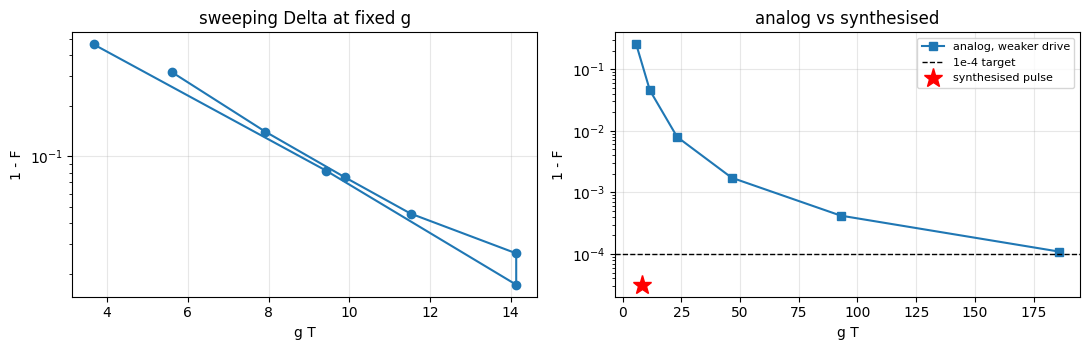

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

ax[0].plot([r[0] for r in sweep], [1 - r[1] for r in sweep], "o-")
ax[0].set_xlabel("g T")
ax[0].set_ylabel("1 - F")
ax[0].set_yscale("log")
ax[0].set_title("sweeping Delta at fixed g")

ax[1].plot([t[0] for t in trade], [1 - t[1] for t in trade], "s-",
           label="analog, weaker drive")
ax[1].axhline(1e-4, color="k", ls="--", lw=1, label="1e-4 target")
ax[1].plot([8.19], [1 - 0.9999683], "r*", ms=14, label="synthesised pulse")
ax[1].set_xlabel("g T")
ax[1].set_ylabel("1 - F")
ax[1].set_yscale("log")
ax[1].set_title("analog vs synthesised")
ax[1].legend(fontsize=8)

for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Verdict

**The idea is sound, and structurally nicer than the sketch suggests.** The three
second-order terms are not three separate problems: with equal rates and $\Delta\phi=\pi$
they are exactly $\sigma_z n_-$, and $\exp$ of that is the controlled SWAP. One pulse, two
numbers to calibrate ($\Delta$ and $T$), no pulse synthesis, no beamsplitters.

### Three corrections to the sketch

1. **The detunings must be equal, not opposite.** $d_2=-d_1$ zeroes the conditional
   beamsplitter identically (the coefficient goes as $1/d_1+1/d_2$) while leaving the
   dynamical $\chi$ — the worst of both worlds. Equal detunings are also the only case
   where a single static rotating frame exists at all, and they are the Raman resonance
   condition for $a_1\to q\to a_2$.
2. **No echo.** The dynamical $\chi$ is *half of the gate*: it is the $N$ part and the
   conditional beamsplitter is the $J_x$ part of the same $n_-$, locked 1:1. Echoing it
   away leaves $\sigma_zJ_x$ — a controlled beamsplitter, never a controlled SWAP. (If a
   partial controlled-BS is what you want, then echo, and re-derive the angle.)
3. **The $|f\rangle$ level is part of the mechanism, not a perturbation.** Because the
   sideband couples to $q$ rather than $\sigma^-$, $|e\rangle$ also pushes against
   $|f\rangle$, giving
   $\delta\chi=2g^2\alpha/[\Delta(\Delta+\alpha)]$ instead of $2g^2/\Delta$ — up to
   $2\times$ faster. Simulating with $N_q=2$ does not give a slightly-off answer, it gives
   the *wrong* answer ($F=0.36$ where the converged value is $0.78$). $N_q=4$ is converged
   to $5\times10^{-6}$; we use $N_q=5$.

### The cost is speed, and it is steep

Scored on total $N\le8$ (cavity Fock $0..4$ each), which is the coverage of the synthesised
pulse in `control_bs.ipynb`:

| $g/2\pi$ | $g\,T$ | $1-F$ |
|---|---|---|
| 4 MHz | 5.8 | $2.5\times10^{-1}$ |
| 2 MHz | 11.6 | $4.5\times10^{-2}$ |
| 1 MHz | 23.2 | $7.9\times10^{-3}$ |
| 0.5 MHz | 46.4 | $1.7\times10^{-3}$ |
| 0.25 MHz | 92.9 | $4.2\times10^{-4}$ |
| 0.125 MHz | 185.8 | $1.1\times10^{-4}$ |

so $10^{-4}$ needs $g\,T\approx190$, against $g\,T=8.19$ at $F=0.9999683$ for the
synthesised pulse on the same range — roughly **$23\times$ slower at matched fidelity and
matched Fock range**. The reason is structural: this is a *perturbative* gate, so its error
falls only as $(g/\Delta)^2$ while its duration grows as $\Delta/g$; a synthesised pulse is
exact by construction and pays no such price. Sweeping $\Delta$ at fixed $g$ does not rescue
it either — $g\,T=\frac{\pi}{4}\frac{|\alpha|}{g}u(1-u)$ is squeezed between the dispersive
breakdown at $u\to0$ and the $ef$ sideband resonance at $u\to1$ (visible as the collapse to
$F=0.54$ at $\Delta/2\pi=140$ MHz, where $\Delta+\alpha=-10$ MHz).

### Where the analog version wins

No optimal control, no per-device pulse table, two calibration numbers. It is an excellent
first thing to try on a new device, a good cross-check on a synthesised gate, and it needs
no cavity–cavity beamsplitter at all. It also stays in the regime Ziqian noted — "relying on
us not driving it too hard" — which is precisely why it is slow.

### Two things not evaluated here

* **Transmon decoherence.** The dynamical $\chi$ means the transmon frequency depends on the
  cavity populations throughout the gate, so photon-number fluctuations dephase the control
  qubit; and one branch sits in $|e\rangle$ for the whole duration. At $g\,T\approx190$ that
  is a long time, and this is exactly the concern raised in the Slack thread. It needs a
  Lindblad treatment to compare fairly.
* **Other pump products.** Only the two intended conversion terms were kept. A real 3WM
  element with two strong pumps also produces pump-induced Stark shifts and, because the two
  pumps differ by $\omega_1-\omega_2$, a spurious direct cavity–cavity beamsplitter. Those
  are calibratable but not free.